In [1]:
import xml.etree.ElementTree as ET
import json
import os

def parse_battery_hierarchy(xml_path):
    try:
        # 1. XML 파일 파싱
        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        # AAS 표준 네임스페이스 처리 (필요 시)
        # namespaces = {'aas': 'http://www.admin-shell.io/aas/3/0'}
        
        hierarchy = {
            "asset_id": "BatteryPack_001",
            "modules": {}
        }
        
        # 2. 계층 구조 탐색 (가이드북의 MXXCVXX 규칙 활용)
        # XML 내의 모든 'idShort' 또는 'value' 태그에서 모듈/셀 정보를 추출합니다.
        for elem in root.iter():
            text = elem.text if elem.text else ""
            
            # 모듈 및 셀 패턴 매칭 (예: M01CV01, M01T01)
            if 'M' in text and ('CV' in text or 'T0' in text):
                parts = text.split('.')
                tag_name = parts[-1] # 마지막 항목 (M01CV01 등)
                
                module_id = tag_name[:3] # M01
                component_id = tag_name # M01CV01
                
                if module_id not in hierarchy["modules"]:
                    hierarchy["modules"][module_id] = {
                        "cells": [],
                        "sensors": []
                    }
                
                if 'CV' in tag_name:
                    hierarchy["modules"][module_id]["cells"].append(component_id)
                elif 'T0' in tag_name:
                    hierarchy["modules"][module_id]["sensors"].append(component_id)

        # 3. 결과 저장
        output_path = '/home/jovyan/project/data/battery_hierarchy.json'
        with open(output_path, 'w', encoding='utf-8') as f:
            json.dump(hierarchy, f, ensure_ascii=False, indent=4)
            
        print(f"✅ 자산 계층 구조 구축 완료: {output_path}")
        print(f"📊 총 {len(hierarchy['modules'])}개의 모듈 구조를 파악했습니다.")

    except Exception as e:
        print(f"❌ XML 파싱 실패: {e}")

# 실행
if __name__ == "__main__":
    # 파일명이 다를 수 있으니 확인 필요
    xml_path = "/home/jovyan/project/data/BatteryPackChargeAndDisChargeTest.xml" 
    if os.path.exists(xml_path):
        parse_battery_hierarchy(xml_path)
    else:
        print(f"⚠️ {xml_path} 파일이 없습니다. 경로를 확인해주세요.")

✅ 자산 계층 구조 구축 완료: /home/jovyan/project/data/battery_hierarchy.json
📊 총 16개의 모듈 구조를 파악했습니다.


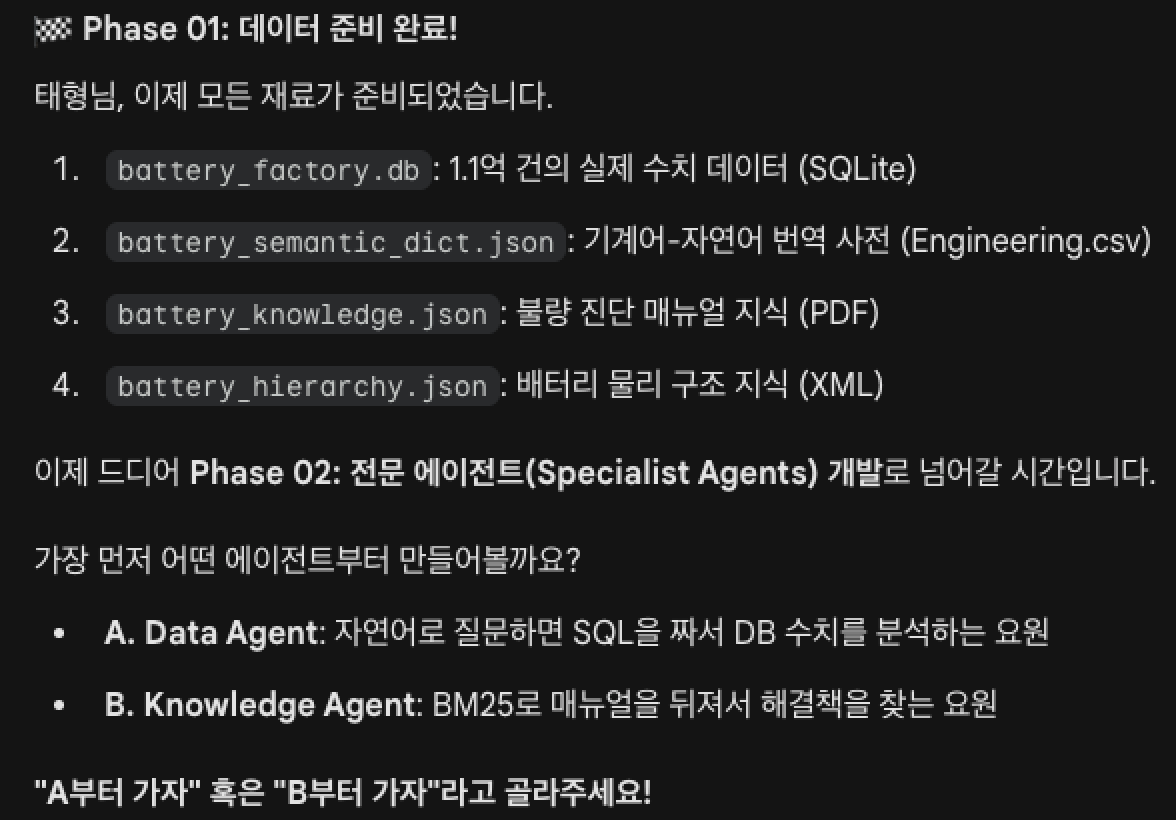